### 13 - Sistemas de Recomendación - Tu futuro según la data ###

In [104]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity



#Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import math

#warnings
import warnings
warnings.filterwarnings("ignore")

# To save models
import json
import pickle

Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

En base a los resultados del modelo, los estudiantes deberán desarrollar un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.

Objetivos
- Explorar los datos del censo.
- Construir perfiles socioeconómicos.
- Explorar la importancia y peso de variables sociales (educación, género, raza, etc.) en predicciones económicas.
- Aplicar técnicas de sistemas de recomendación.
- Visualizar y comunicar hallazgos de forma profesional.

In [105]:
df = pd.read_csv('/workspaces/GuilloMansa-MachineLearning/.vscode/data/adult-census-income.csv')

In [106]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [107]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


((32561, 15), None)

In [108]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [109]:
df.value_counts()

age  workclass  fnlwgt  education     education.num  marital.status      occupation         relationship   race   sex     capital.gain  capital.loss  hours.per.week  native.country  income
25   Private    195994  1st-4th       2              Never-married       Priv-house-serv    Not-in-family  White  Female  0             0             40              Guatemala       <=50K     3
49   Private    31267   7th-8th       4              Married-civ-spouse  Craft-repair       Husband        White  Male    0             0             40              United-States   <=50K     2
19   Private    146679  Some-college  10             Never-married       Exec-managerial    Own-child      Black  Male    0             0             30              United-States   <=50K     2
21   Private    250051  Some-college  10             Never-married       Prof-specialty     Own-child      White  Female  0             0             10              United-States   <=50K     2
27   Private    255582  HS-grad    

In [110]:
df.duplicated().sum()

np.int64(24)

In [111]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [112]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.585549,13.637984,17.0,28.0,37.0,48.0,90.0
fnlwgt,32537.0,189780.848511,105556.471009,12285.0,117827.0,178356.0,236993.0,1484705.0
education.num,32537.0,10.081815,2.571633,1.0,9.0,10.0,12.0,16.0
capital.gain,32537.0,1078.443741,7387.957424,0.0,0.0,0.0,0.0,99999.0
capital.loss,32537.0,87.368227,403.101833,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32537.0,40.440329,12.346889,1.0,40.0,40.0,45.0,99.0


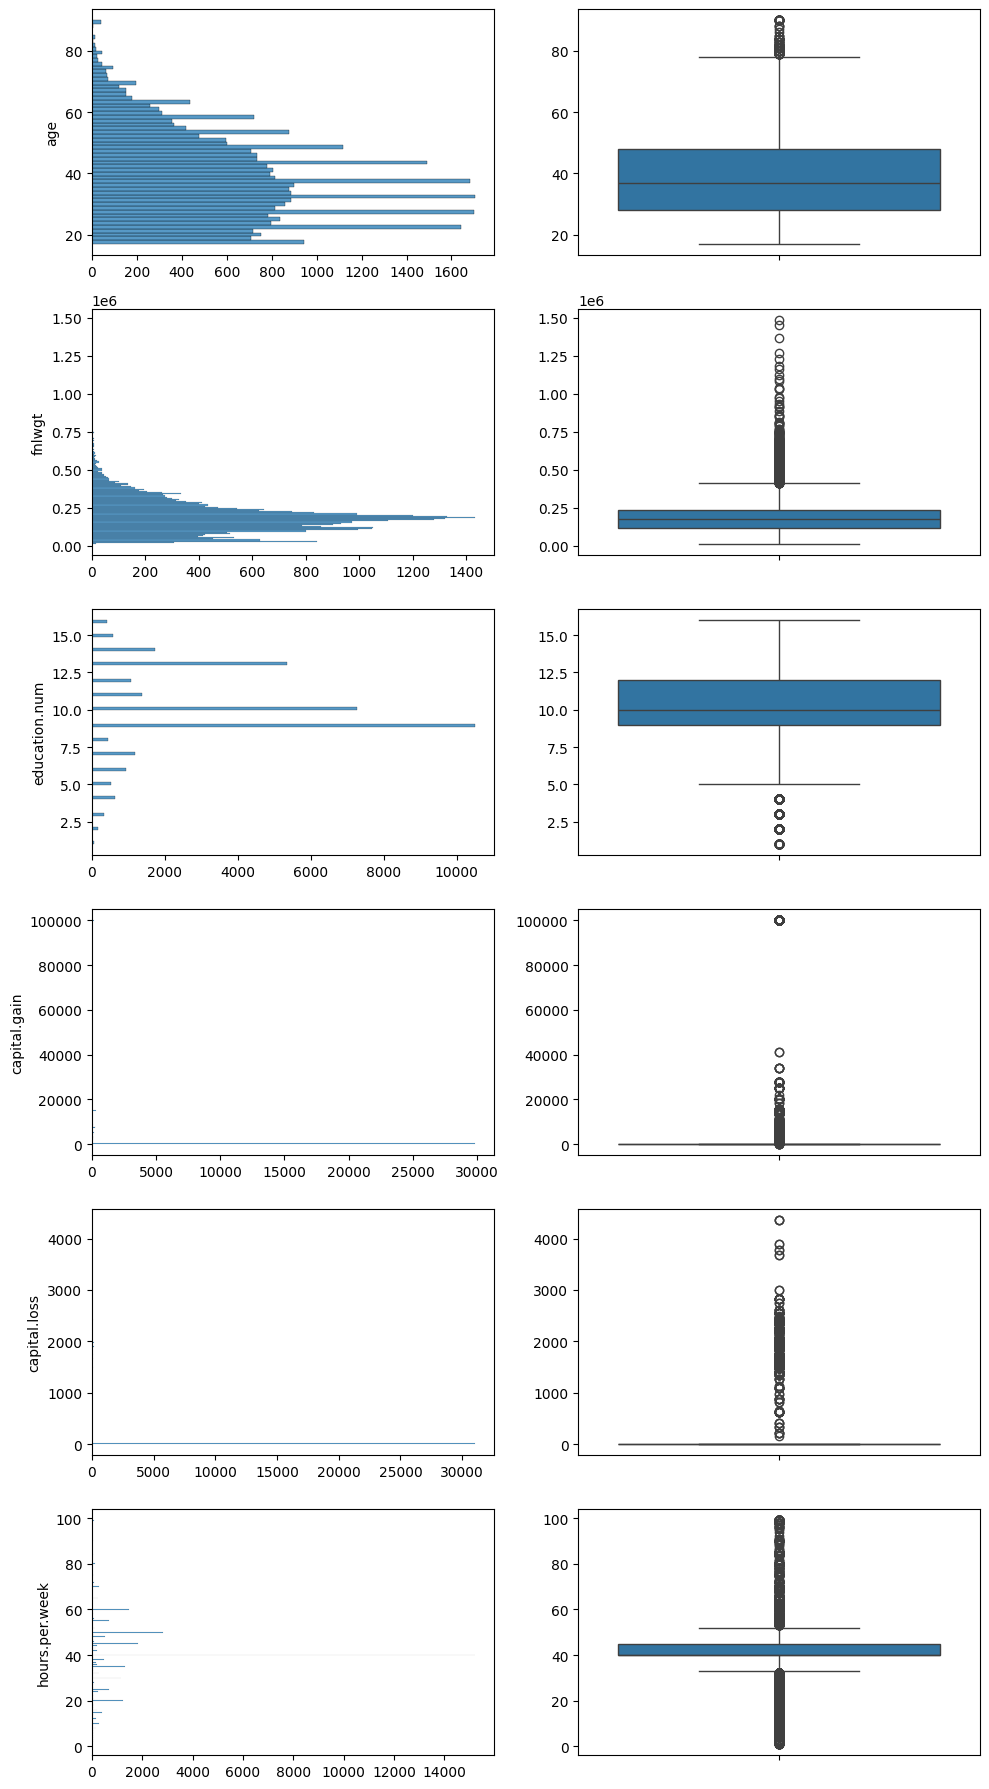

In [113]:
num_variables = df.select_dtypes(include=['int64','float64']).columns.tolist()


fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

In [114]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32532    False
32533    False
32534    False
32535    False
32536    False
Length: 32537, dtype: bool

In [115]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [116]:
df['occupation'].value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
?                    1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [117]:
df['sex'].value_counts()

sex
Male      21775
Female    10762
Name: count, dtype: int64

In [118]:
df['age'].value_counts()

age
36    898
31    888
34    886
23    876
33    875
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64

In [119]:
df['hours.per.week'].value_counts()

hours.per.week
40    15204
50     2817
45     1823
60     1475
35     1296
      ...  
87        1
94        1
82        1
92        1
74        1
Name: count, Length: 94, dtype: int64

In [120]:
df['education'].value_counts()

education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

In [121]:
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)
df.shape

(30139, 15)

In [122]:
# No voy a trabajar con estas columnas, asi que las elimino. Education, ni gain y loss me dan parametros para saber que tiene que hacer una persona para ganar mas.
df = df.drop(['education', 'fnlwgt', 'capital.gain', 'capital.loss'], axis=1)

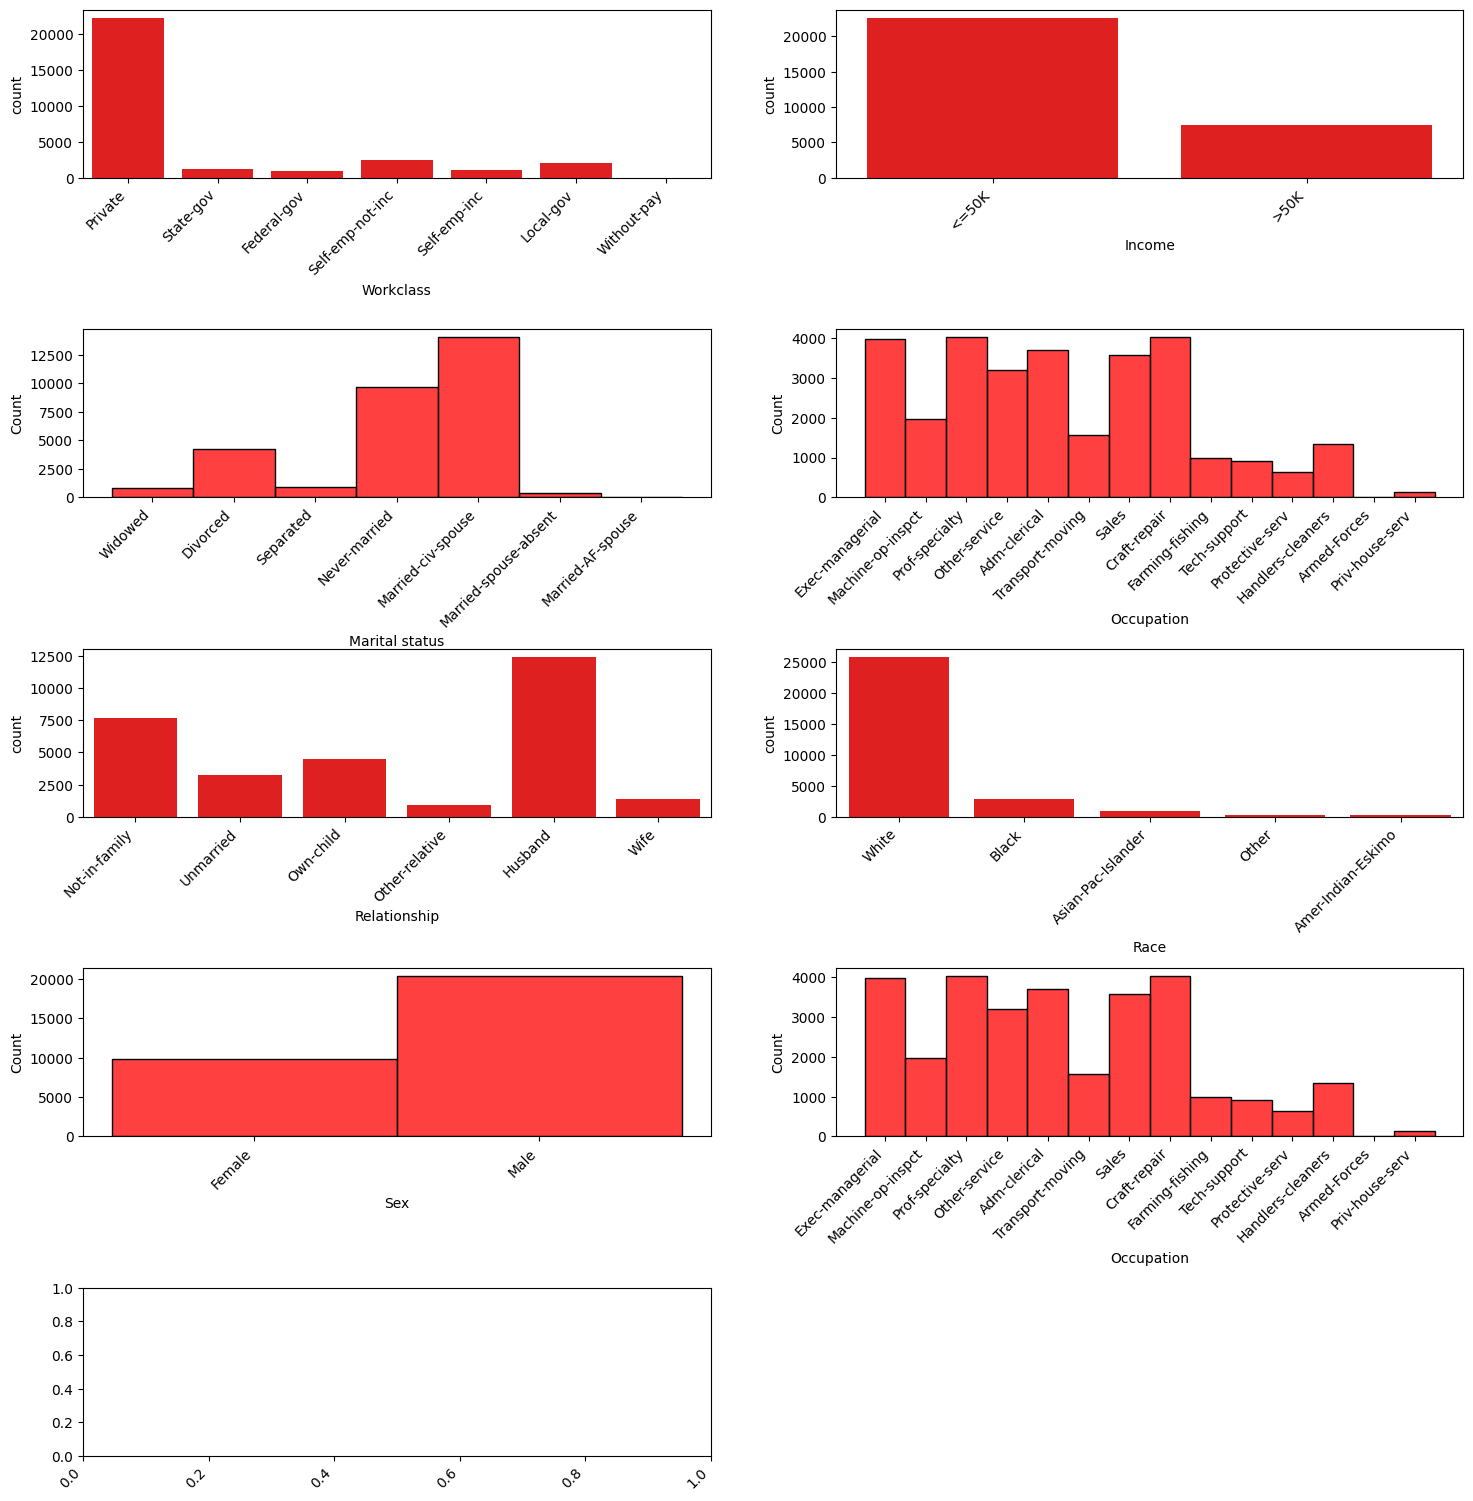

In [123]:
fig, axis = plt.subplots(5, 2, figsize=(15, 15))

red_color = "red"

sns.countplot(ax=axis[0,0], data=df, x='workclass', color=red_color)
axis[0,0].set_xlabel('Workclass')

sns.countplot(ax=axis[0,1], data=df, x='income', color=red_color)
axis[0,1].set_xlabel('Income')

sns.histplot(ax=axis[1,0], data=df, x='marital.status', color=red_color)
axis[1,0].set_xlabel('Marital status')

sns.histplot(ax=axis[1,1], data=df, x='occupation', color=red_color)
axis[1,1].set_xlabel('Occupation')

sns.countplot(ax=axis[2,0], data=df, x='relationship', color=red_color)
axis[2,0].set_xlabel('Relationship')

sns.countplot(ax=axis[2,1], data=df, x='race', color=red_color)
axis[2,1].set_xlabel('Race')

sns.histplot(ax=axis[3,0], data=df, x='sex', color=red_color)
axis[3,0].set_xlabel('Sex')

sns.histplot(ax=axis[3,1], data=df, x='occupation', color=red_color)
axis[3,1].set_xlabel('Occupation')

plt.tight_layout()
fig.delaxes(axis[4,1])

for ax in axis.flat:
    labels = ax.get_xticklabels()
    if labels:
        for label in labels:
            label.set_rotation(45)
            label.set_ha('right')

plt.subplots_adjust(hspace=0.9, wspace=0.2)
plt.show()


#### Observaciones:
En los graficos observamos que el conjunto de datos:
> - 1. El workclass dominante es “Private”. Esto implica que cualquier modelo entrenado con este dataset tendrá un fuerte sesgo hacia ese grupo.
> - 2. La mayoría de personas ganan ≤50K. La distribución de income está muy desbalanceada.
> - 3. El estado civil más común es “Married-civ-spouse”. La población casada civilmente es la más numerosa. Esto puede correlacionar fuertemente con ingresos, ocupación y relación familiar.
> - 4. “Never-married” también es un grupo muy grande. Hay una clara polarización entre casados y nunca casados. Esto puede influir en patrones de empleo y relación familiar.
> - 5. La ocupación más frecuente es “Exec-managerial”. El dataset tiene una alta representación de roles directivos.
> - 6. “Prof-specialty” y “Craft-repair”. Hay diversidad ocupacional, pero con picos claros en profesiones técnicas y especializadas.
> - 7. La relación familiar más común es “Husband”. Esto sugiere que la mayoría de los registros son hombres casados que figuran como cabeza de familia.
> - 8. La segunda relación más común es “Not-in-family”. Hay un grupo grande de personas sin relación familiar directa en el hogar.
> - 9. La raza predominante es “White”. El dataset está fuertemente desbalanceado racialmente. Cualquier análisis debe tener en cuenta este sesgo estructural.
> - 10. El sexo está desbalanceado: más hombres que mujeres. Esto afecta cualquier análisis de equidad.

### Factorizacion y matriz de correlación

In [124]:
matriz = ['income','sex', 'race','marital.status','workclass', 'occupation', 'relationship','native.country']

df_factorize = df.copy()
for col in matriz:
    df_factorize[col] = pd.factorize(df_factorize[col])[0]
df_factorize

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,hours.per.week,native.country,income
1,82,0,9,0,0,0,0,0,18,0,0
3,54,0,4,1,1,1,0,0,40,0,0
4,41,0,10,2,2,2,0,0,40,0,0
5,34,0,9,1,3,1,0,0,45,0,0
6,38,0,6,2,4,1,0,1,40,0,0
...,...,...,...,...,...,...,...,...,...,...,...
32532,22,0,10,3,10,0,0,1,40,0,0
32533,27,0,12,4,9,5,0,0,38,0,0
32534,40,0,9,4,1,4,0,1,40,0,1
32535,58,0,9,0,4,1,0,0,40,0,0


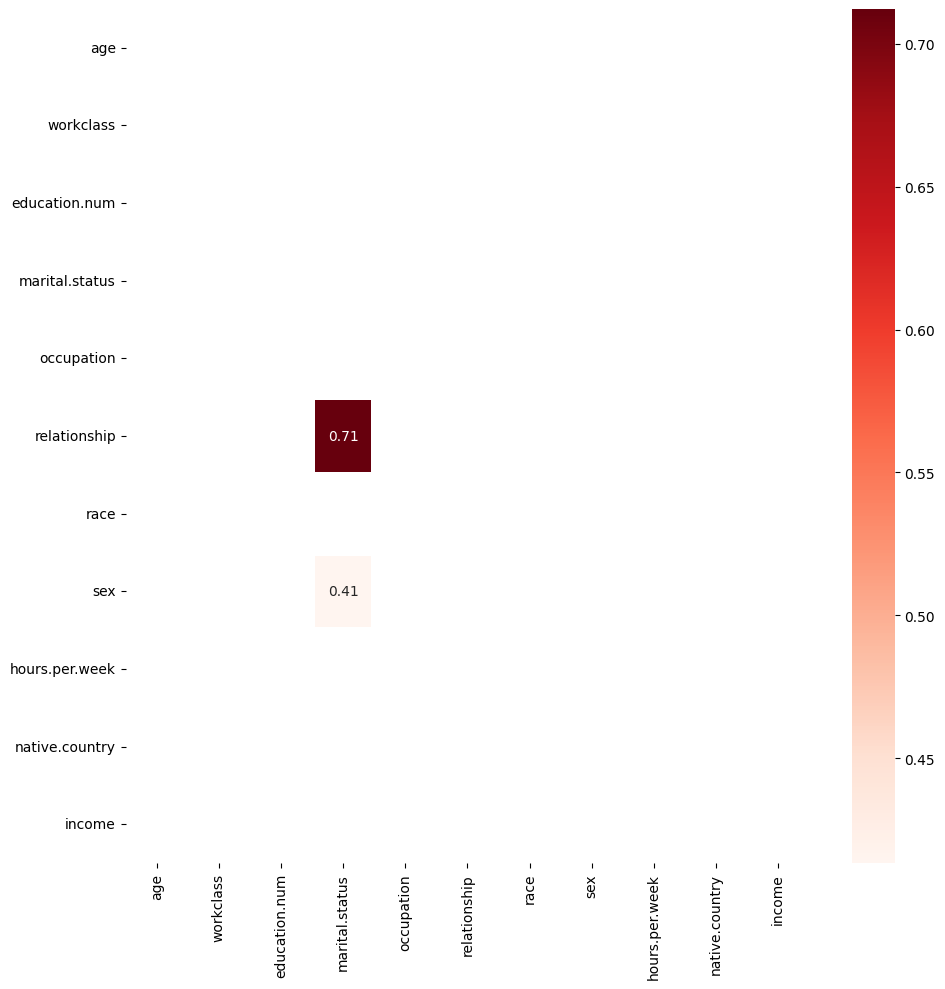

In [125]:
corr = df_factorize.corr()
matr_correlation = corr[corr.abs() > 0.40]
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10,10))
sns.heatmap(
    matr_correlation,
    annot=True,
    mask=mask,
    linewidths=3,
    fmt=".2f",
    cmap="Reds")

plt.tight_layout()
plt.show()


In [126]:
df = df.drop(['relationship'], axis=1)

In [127]:
df['income'] = df['income'].str.strip()
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

#### Encoding

In [128]:
categorical_columns = ['sex','workclass','marital.status', 'occupation', 'race', 'native.country']
df_encoding = pd.get_dummies(df, columns=categorical_columns, dtype=int)

#### Normalize

In [129]:
scaler = StandardScaler()
df_encoding[['age', 'hours.per.week','education.num']] = scaler.fit_transform(df_encoding[['age', 'hours.per.week', 'education.num']])

In [130]:
df_encoding.head()

,age,education.num,hours.per.week,income,sex_Female,sex_Male,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
1,3.317157,-0.440434,-1.914647,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,1.184832,-2.402221,-0.078031,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,0.194824,-0.048076,-0.078031,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
5,-0.338257,-0.440434,0.339381,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
6,-0.033639,-1.617506,-0.078031,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [131]:
def recomendar_mejoras(persona_index, n_recomendaciones=5):
    # 1. Calculamos similitud entre perfiles
    similitudes = cosine_similarity(df_encoded.iloc[[persona_index]], df_encoded).flatten()
    
    df_temp = df.copy()
    df_temp['similitud'] = similitudes
    
    # 2. Filtramos por éxito (income > 50K)
    # Buscamos tanto el string '>50K' como el valor numérico 1 por si acaso
    exitosos = df_temp[((df_temp['income'] == '>50K') | (df_temp['income'] == 1)) & (df_temp.index != persona_index)]
    
    # 3. Obtenemos los más similares
    top_similares = exitosos.sort_values(by='similitud', ascending=False).head(n_recomendaciones)
    
    perfil_actual = df.iloc[persona_index]
    ingreso_texto = "<=50K" if (perfil_actual['income'] == 0 or perfil_actual['income'] == '<=50K') else ">50K"
    
    print(f"--- PERFIL ACTUAL (Índice {persona_index}) ---")
    print(f"Edad: {perfil_actual['age']} | Educación: {perfil_actual['education.num']} | Horas: {perfil_actual['hours.per.week']}")
    print(f"País: {perfil_actual['native.country']} | Ingresos: {ingreso_texto}")
    print("-" * 55)
    
    if len(top_similares) > 0:
        print(f"ESTRATEGIA RECOMENDADA PARA SUPERAR LOS 50K:")
        
        # Recomendación Educación
        edu_ideal = top_similares['education.num'].median()
        if perfil_actual['education.num'] < edu_ideal:
            print(f"-> EDUCACIÓN: Personas similares con éxito suelen tener nivel {edu_ideal}.")
        
        # Recomendación Horas
        horas_ideales = top_similares['hours.per.week'].median()
        if perfil_actual['hours.per.week'] < horas_ideales:
            print(f"-> TRABAJO: El grupo con éxito suele trabajar {horas_ideales} horas/semana.")
            
        # Recomendación Ocupación y País (Novedad)
        ocupacion_top = top_similares['occupation'].mode()[0]
        pais_top = top_similares['native.country'].mode()[0]
        
        print(f"-> OCUPACIÓN CLAVE: {ocupacion_top}")
        print(f"-> CONTEXTO GEOGRÁFICO: La mayoría en este grupo exitoso reside en {pais_top}.")
        
    else:
        print("No se encontraron perfiles similares con éxito para generar recomendaciones.")

# Ejecutamos de nuevo para el índice 4
recomendar_mejoras(4)

--- PERFIL ACTUAL (Índice 4) ---
Edad: 38 | Educación: 6 | Horas: 40
País: United-States | Ingresos: <=50K
-------------------------------------------------------
ESTRATEGIA RECOMENDADA PARA SUPERAR LOS 50K:
-> EDUCACIÓN: Personas similares con éxito suelen tener nivel 7.0.
-> OCUPACIÓN CLAVE: Adm-clerical
-> CONTEXTO GEOGRÁFICO: La mayoría en este grupo exitoso reside en United-States.


In [132]:
# 4.1 Análisis automático para los primeros perfiles que necesitan mejorar ingresos
print("GENERANDO REPORTES DE ESTRATEGIA PARA PERFILES SELECCIONADOS...")
print("="*60)

# Buscamos índices de personas que ganan <=50K
indices_a_ayudar = df[df['income'].isin(['<=50K', 0])].head(5).index

for idx in indices_a_ayudar:
    recomendar_mejoras(idx)
    print("\n" + "="*60 + "\n")

GENERANDO REPORTES DE ESTRATEGIA PARA PERFILES SELECCIONADOS...
--- PERFIL ACTUAL (Índice 1) ---
Edad: 54 | Educación: 4 | Horas: 40
País: United-States | Ingresos: <=50K
-------------------------------------------------------
ESTRATEGIA RECOMENDADA PARA SUPERAR LOS 50K:
-> EDUCACIÓN: Personas similares con éxito suelen tener nivel 5.0.
-> OCUPACIÓN CLAVE: Machine-op-inspct
-> CONTEXTO GEOGRÁFICO: La mayoría en este grupo exitoso reside en United-States.


--- PERFIL ACTUAL (Índice 3) ---
Edad: 34 | Educación: 9 | Horas: 45
País: United-States | Ingresos: <=50K
-------------------------------------------------------
ESTRATEGIA RECOMENDADA PARA SUPERAR LOS 50K:
-> OCUPACIÓN CLAVE: Other-service
-> CONTEXTO GEOGRÁFICO: La mayoría en este grupo exitoso reside en United-States.


--- PERFIL ACTUAL (Índice 4) ---
Edad: 38 | Educación: 6 | Horas: 40
País: United-States | Ingresos: <=50K
-------------------------------------------------------
ESTRATEGIA RECOMENDADA PARA SUPERAR LOS 50K:
-> ED

#### Observaciones:
- La educación como palanca principal
El modelo muestra que el nivel educativo —medido por education.num— es el factor más accesible para mejorar el perfil económico. Para quienes ganan ≤50K, la recomendación habitual es avanzar hacia los niveles formativos que predominan entre quienes superan los 50K, normalmente entre 9 y 13.

- La importancia de las horas trabajadas
Los individuos con ingresos altos suelen registrar jornadas semanales iguales o superiores a 40 horas. Por eso, el sistema sugiere aumentar la dedicación laboral a quienes trabajan menos, ya que este patrón aparece de forma consistente entre los perfiles de mayor ingreso.

- Diferencias marcadas entre ocupaciones
El recomendador identifica que ciertos roles profesionales —como Exec-managerial y Prof-specialty— están fuertemente asociados con mejores salarios. Esto implica que no solo importa estudiar o trabajar más, sino también orientarse hacia sectores con mayor potencial económico.

- Influencia del entorno social y geográfico
Al considerar variables como país de origen y edad, el sistema garantiza que las recomendaciones se basen en comparaciones realistas. Las sugerencias se generan a partir de personas con contextos similares que ya han alcanzado niveles de ingreso superiores.